In [78]:
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u



import numpy as np
import matplotlib.pyplot as plt
import galsim

from astropy.io.votable import parse
from scipy.interpolate import interp1d


# import gala.coordinates as gc
import astropy.coordinates as coord

from scipy.optimize import curve_fit

from scipy import integrate

import sys 
# Calculate the parent directory and add it to sys.path
parent_dir = '/sdf/home/m/mredden/DifferentialCR'
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# print(sys.path)

from utils import synth_fnu
from utils import print_dp1_object_summary
from utils import add_zenith_coordinates
from utils import parallactic_angle_from_radec_fast


from astropy.constants import c
import astropy.units as u
from astropy.table import Table, join, vstack
from utils import BB, apply_filter
from utils import apply_DCR, mean_and_std

import lsst.sphgeom as sphgeom
from concurrent.futures import ThreadPoolExecutor, as_completed

from lsst.daf.butler import Butler

# Coordinates of the observatory:
lat = -30.244633 #-30:14:40.68
lon = -70.749417 #-70:44:57.90
height = 2647 

from utils import radec_to_altaz

 


In [79]:

try:
    #if on the RSP...
    from lsst.rsp import get_tap_service
    service = get_tap_service("tap")
    
    def queryTAP(query):
        job = service.submit_job(query)
        job.run()
        job.wait(phases=['COMPLETED', 'ERROR'])
        print('Job phase is', job.phase)
        if job.phase == 'ERROR':
            job.raise_if_error()
        assert job.phase == 'COMPLETED'
        return job.fetch_result().to_table()
except:
    #if using API...
    from APIaccess import queryTAP

    

In [103]:
# Run an object search 

# # J100201+020330 (COSMOS Field)
ra, dec = 150.506300, 2.058100 # quasar
ra, dec = 150.504722, 2.03530015 # red star (Teff 3337)

# ra,dec = 10.169, -43.884 #ELAISS
# ra, dec = 61.463, -48.347 #EDFS
# ra,dec = 150.248, 2.231 #COSMOS
ra,dec = 53.088, -27.521 #ECDFS

field = 'TRIFID'

if field == 'TRIFID':
    ra, dec = 271.607 , -23.058 #TRIFID
elif field == 'SV225':
    ra, dec = 224.762, -39.421
elif field == 'SV212':
    ra, dec = 212.116, -6.694
elif field == 'SV216':
    ra, dec = 216.309, -17.107
elif field == 'M49':
    ra, dec = 186.722, 6.694
elif field == 'NH':
    ra, dec = 289.258, -20.083


ra,dec = 150.248, 2.231 #COSMOS
# ra,dec = 53.088, -27.521 #ECDFS

search_radius = 3600/3600 * 1
# search_region = sphgeom.Region.from_ivoa_pos(f"CIRCLE {ra} {dec} {search_radius}")
# print(search_region)


# object_table = get_object(ra,dec, search_radius = search_radius, limit_search = False, type = 'galaxy', SNR = 15, multiple_patches = True)


# ---- Object Query ----

query = f"""SELECT coord_dec,
            coord_ra,
            g_cModelMag, g_cModelMagErr,
            r_cModelMag, r_cModelMagErr,
            i_cModelMag, i_cModelMagErr,
            u_cModelMag, u_cModelMagErr,
            z_cModelMag, z_cModelMagErr,
            shape_xx, shape_xy, shape_yy,
            u_inputCount, g_inputCount, r_inputCount, i_inputCount,
            refBand,
            objectId,
            g_ixx, g_iyy, g_ixy,
            g_ixxPSF, g_iyyPSF, g_ixyPSF,
            refExtendedness,
            g_blendedness_flag, g_centroid_flag, g_i_flag
            g_calib_psf_reserved,
            g_calib_psf_used,
            g_cModelMag - r_cModelMag as g_minus_r,
            g_cModelMag - i_cModelMag as g_minus_i,
            r_cModelMag - z_cModelMag as r_minus_z,
            u_cModelMag - g_cModelMag as u_minus_g
    FROM dp2.Object 
    WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec),CIRCLE('ICRS', {ra}, {dec}, {search_radius}))=1
            AND (g_cModelMag < 27 AND g_cModelMag > 19)
            AND refExtendedness > 0.1
            AND g_cModelFlux/g_cModelFluxErr > 10
            """

object_table = queryTAP(query)

object_table_all = object_table.copy()
print(len(object_table))

Job phase is COMPLETED
520518


(array([  121.,   167.,   190.,   216.,   245.,   315.,   410.,   469.,
          538.,   692.,   778.,   962.,  1079.,  1397.,  1625.,  1960.,
         2241.,  2723.,  3146.,  3836.,  4545.,  5619.,  6785.,  8403.,
        10298., 12699., 15293., 18730., 22335., 26017., 29966., 34554.,
        38378., 42027., 45514., 49297., 50975., 44458., 26482.,  5033.]),
 array([19.00180054, 19.18044472, 19.35909081, 19.53773499, 19.71638107,
        19.89502525, 20.07366943, 20.25231552, 20.4309597 , 20.60960579,
        20.78824997, 20.96689606, 21.14554024, 21.32418442, 21.50283051,
        21.68147469, 21.86012077, 22.03876495, 22.21741104, 22.39605522,
        22.5746994 , 22.75334549, 22.93198967, 23.11063576, 23.28927994,
        23.46792603, 23.64657021, 23.82521439, 24.00386047, 24.18250465,
        24.36115074, 24.53979492, 24.71844101, 24.89708519, 25.07572937,
        25.25437546, 25.43301964, 25.61166382, 25.79030991, 25.96895599,
        26.14760017]),
 <BarContainer object of 40 art

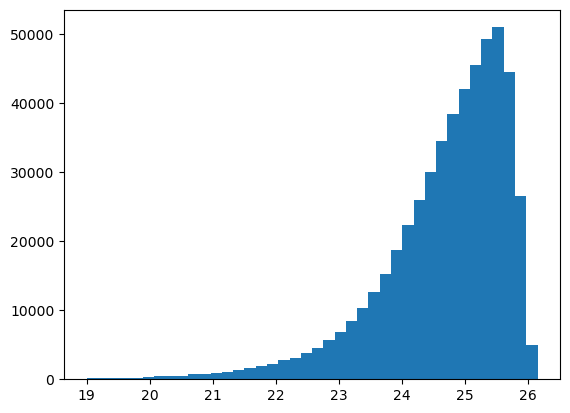

In [104]:
plt.hist(object_table['g_cModelMag'], 40)

0 0
0 1
1 0
1 1


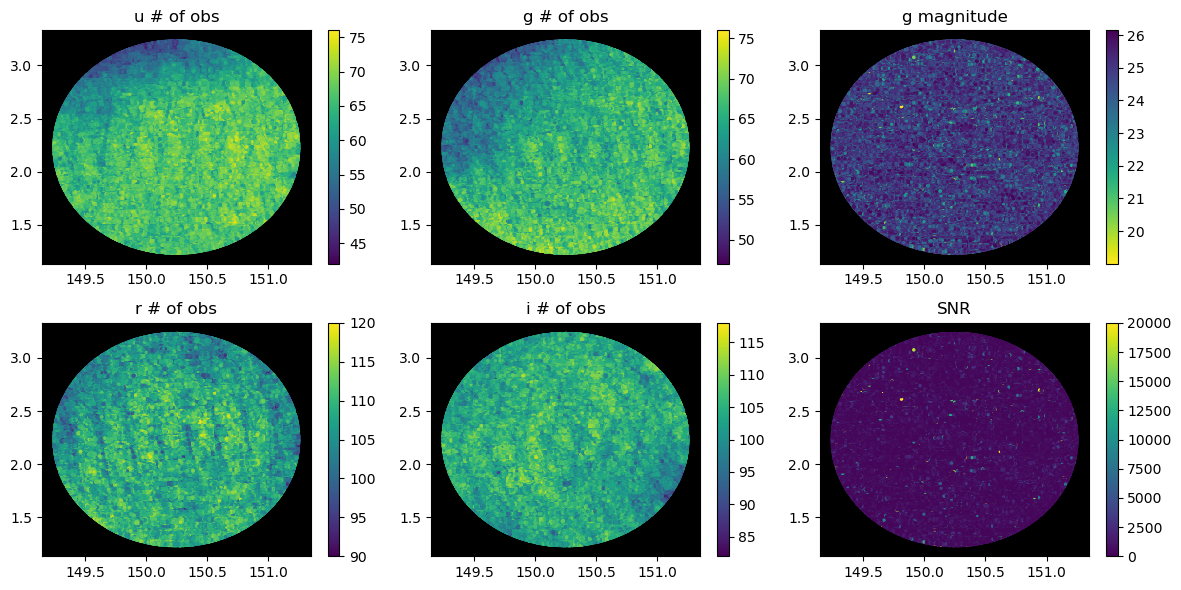

In [105]:
colormap = object_table['g_inputCount']
# colormap = object_table['g_cModelMag']/object_table['g_cModelMagErr']

# sc = plt.scatter(object_table['coord_ra'], object_table['coord_dec'],s = 2,  c = colormap)
# plt.plot(ra, dec, 'r*', markersize = 20)

# plt.colorbar(sc)

fig, ax = plt.subplots(2, 3, figsize=(12, 6))

for i, band in enumerate('ugri'):
    m, n = i // 2, i % 2
    print(m, n)
    colormap = object_table[f'{band}_inputCount']
    sc = ax[m,n].scatter(object_table['coord_ra'], object_table['coord_dec'],s = 2,  c = colormap)
    fig.colorbar(sc, ax = ax[m,n])
    ax[m,n].set_title(f'{band} # of obs')
    ax[m,n].set_facecolor('black')


colormap = object_table['g_cModelMag']

sc = ax[0, 2].scatter(object_table['coord_ra'], object_table['coord_dec'],s = 2,  c = colormap, cmap='viridis_r')
fig.colorbar(sc, ax = ax[0, 2])
ax[0,2].set_title(f'g magnitude')
ax[0,2].set_facecolor('black')


colormap = object_table['g_cModelMag']/object_table['g_cModelMagErr']

sc = ax[1, 2].scatter(object_table['coord_ra'], object_table['coord_dec'],s = 2,  c = colormap, vmin = 0, vmax = 20000)
fig.colorbar(sc, ax = ax[1, 2])
ax[1, 2].set_title(f'SNR')
ax[1, 2].set_facecolor('black')

fig.tight_layout()

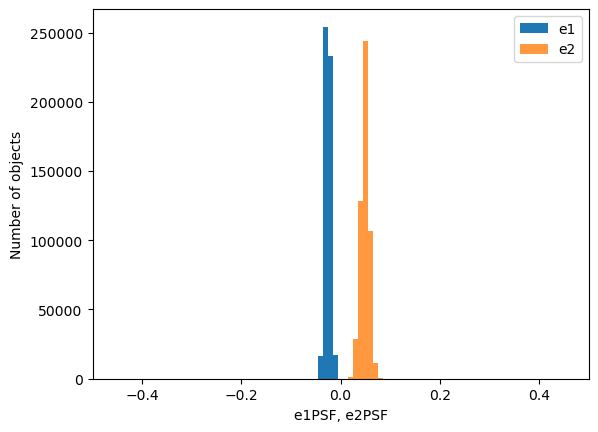

11607


coord_dec,coord_ra,g_cModelMag,g_cModelMagErr,r_cModelMag,r_cModelMagErr,i_cModelMag,i_cModelMagErr,u_cModelMag,u_cModelMagErr,z_cModelMag,z_cModelMagErr,shape_xx,shape_xy,shape_yy,u_inputCount,g_inputCount,r_inputCount,i_inputCount,refBand,objectId,g_ixx,g_iyy,g_ixy,g_ixxPSF,g_iyyPSF,g_ixyPSF,refExtendedness,g_blendedness_flag,g_centroid_flag,g_calib_psf_reserved,g_calib_psf_used,g_minus_r,g_minus_i,r_minus_z,u_minus_g
deg,deg,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,pix2,pix2,pix2,,,,,,,pix2,pix2,pix2,pix2,pix2,pix2,,,,,,,,,
float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,int32,int32,int32,str1,int64,float32,float32,float32,float32,float32,float32,float32,bool,bool,bool,bool,float64,float64,float64,float64
1.586408872323671,149.50142492295095,25.2724,0.0803395,23.7639,0.0220594,22.6085,0.0166634,26.38,0.408766,21.753,0.0138547,8.31722,-0.996065,8.39377,65,67,111,101,z,788004178147435121,14.1658,9.56036,0.183744,5.15201,5.36604,0.274367,1.0,False,False,False,False,1.508523941040039,2.6638736724853516,2.0108985900878906,1.1075687408447266
1.5832074271564451,149.49660673752967,24.0716,0.0296385,23.5165,0.0240925,23.0658,0.0319471,24.3434,0.0812718,22.9,0.159946,14.7059,-6.00286,22.9117,65,68,111,100,u,788004178147435128,19.7871,21.3176,-11.0857,5.15201,5.36604,0.274367,1.0,True,True,True,False,0.5550861358642578,1.0057525634765625,0.6165218353271484,0.27184104919433594
1.5815755224640862,149.49637716287032,25.157,0.0573804,24.0986,0.0356893,23.2853,0.0232782,26.1815,0.357325,22.6695,0.0456483,7.85524,1.17889,8.51201,65,68,111,97,i,788004178147435125,10.7712,10.0965,3.55894,5.15201,5.36604,0.274367,1.0,False,False,False,False,1.0583438873291016,1.8717079162597656,1.4291648864746094,1.024545669555664
1.5789711569814546,149.49377581398497,25.258,0.0515499,24.3624,0.0301359,23.9439,0.0321166,25.4694,0.157957,23.841,0.0709266,6.0571,-0.0900816,5.4066,67,70,112,102,r,788004178147435101,4.71694,6.40897,-0.118811,5.35336,5.54591,0.271766,1.0,False,False,False,False,0.8955535888671875,1.3140754699707031,0.5213851928710938,0.21142578125
1.579625281343072,149.49513025363078,24.1778,0.0327197,23.5632,0.0240522,23.3198,0.0348089,24.9358,0.135975,23.3127,0.0797317,13.887,-0.742089,15.8672,65,68,111,101,r,788004178147435098,26.0301,19.2053,4.47954,5.21822,5.40513,0.27414,1.0,True,True,True,False,0.6145782470703125,0.8580417633056641,0.250579833984375,0.7579822540283203
1.5795557393639446,149.49660518221341,24.7597,0.0361823,24.1229,0.0285595,23.8848,0.0378923,25.5778,0.182695,23.7971,0.0910555,8.44847,1.07793,7.46737,65,67,112,98,r,788004178147435097,7.83959,6.43452,0.754403,5.21822,5.40513,0.27414,1.0,False,False,False,False,0.6367645263671875,0.8748264312744141,0.3257617950439453,0.818115234375
1.581339425708036,149.48837032135052,25.0059,0.0484022,24.7491,0.0525263,24.8156,0.0815611,25.4068,0.17693,24.599,0.17171,8.31915,-1.41422,2.32914,64,72,114,102,i,788004178147435193,6.60555,5.9173,0.715097,5.24152,5.46408,0.270065,1.0,True,True,True,False,0.2567863464355469,0.19020462036132812,0.1500873565673828,0.40091514587402344
1.5806582753722223,149.48936325159607,25.0103,0.041878,24.4565,0.0337423,24.0986,0.0378471,25.1318,0.11956,23.7273,0.066917,5.53125,-0.638088,4.73923,64,71,113,103,i,788004178147435192,7.44226,7.61565,0.989837,5.35336,5.54591,0.271766,1.0,False,False,False,False,0.5537681579589844,0.9116706848144531,0.7291622161865234,0.12153434753417969


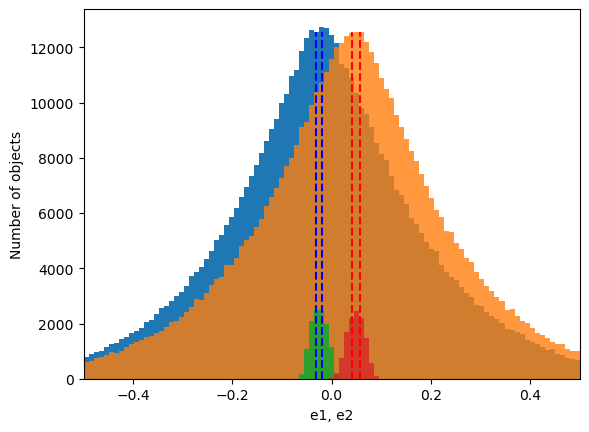

In [109]:
#select only extended and circular objects
# to select for round objects, the distribution of e1 and e2 should look approximately like 
# the distribution of e1PSF and e2PSF, which are the PSF ellipticities
# the problem with using this method is that we are specifically looking for 
# galaxies which might not match the PSF due to their different SEDs, so
# we're possibly cutting out objects that we're most interested in 

TPSF = object_table_all['g_ixxPSF'] + object_table_all['g_iyyPSF']
e1PSF = (object_table_all['g_ixxPSF'] - object_table_all['g_iyyPSF'])/TPSF
e2PSF = 2*object_table_all['g_ixyPSF'] / TPSF

bins = np.linspace(-0.5, 0.5, 100)
n, bins_, _ = plt.hist(e1PSF ,bins, label = 'e1')
plt.hist(e2PSF, bins, alpha = 0.8, label = 'e2')
plt.xlabel('e1PSF, e2PSF')
plt.ylabel('Number of objects')
plt.xlim(-0.5, 0.5)
plt.legend()
plt.show()
plt.close()

e1_median = np.median(e1PSF)
e1_width = np.std(e1PSF)*1

e2_median = np.median(e2PSF)
e2_width = np.std(e2PSF)*1


T =  object_table_all['g_ixx'] + object_table_all['g_iyy']
e1 = (object_table_all['g_ixx'] - object_table_all['g_iyy'])/T
e2 = 2*object_table_all['g_ixy'] / T

plt.hist(e1 ,bins, label = 'e1')
n, _, _ = plt.hist(e2, bins, alpha = 0.8, label = 'e2')
plt.vlines([e1_median - e1_width, e1_median + e1_width], ymin=0, ymax=np.max(n), colors='b', linestyles='dashed', label='Median')
plt.vlines([e2_median - e2_width, e2_median + e2_width], ymin=0, ymax=np.max(n), colors='r', linestyles='dashed', label='Median')
plt.xlabel('e1, e2')
plt.ylabel('Number of objects')
plt.xlim(-0.5, 0.5)



shape_mask_old = (np.abs(e1) < 0.05) & (np.abs(e2) < 0.05)
# shape_mask = (e1  < e1_median + e1_width) & (e1 > e1_median - e1_width) & (e2 < e2_median + e2_width) & (e2 > e2_median - e2_width)
shape_mask = np.sqrt((np.abs(e1 - e1PSF)**2 + np.abs(e2 - e2PSF)**2)) < 0.03
mask = shape_mask #& (object_table['refExtendedness'] > 0.1) 
print(np.sum(shape_mask))

plt.hist(e1[mask] ,bins)
plt.hist(e2[mask], bins, alpha = 0.8)

object_table = object_table_all #[mask]
object_table


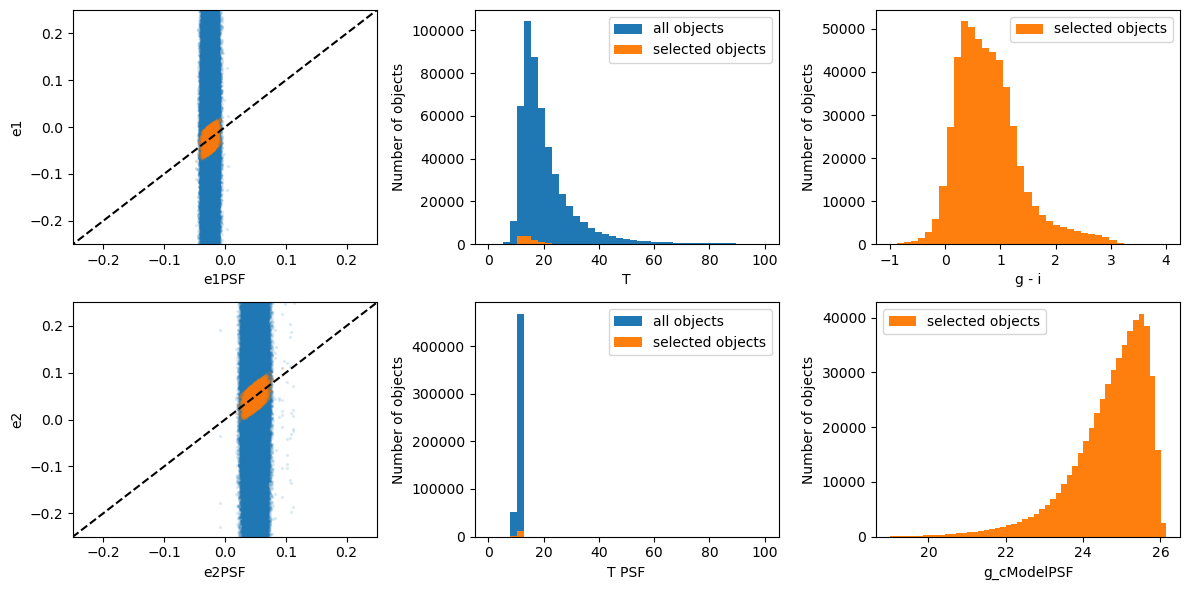

In [110]:
# Object summary plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 3, figsize=(12, 6))


# # 
# i, j = 0, 0
# bins = np.linspace(-0.5, 0.5, 100)
# ax[i, j].hist(e1, bins, label = 'e1')
# ax[i, j].hist(e2, bins, alpha = 0.8, label = 'e2')
# ax[i, j].hist(e1[mask], bins, label = 'e1[mask]')
# ax[i, j].hist(e2[mask], bins, alpha = 0.8, label = 'e2[mask]')
# # ax[i, j].vlines([-0.03, 0.03], ymin=0, ymax=np.max(n), colors='k', linestyles='dashed', label='Median')
# ax[i, j].set_xlabel('e1 , e2 ')
# ax[i, j].set_ylabel('Number of objects') 
# ax[i, j].legend()


# i, j = 1,0 
# bins = np.linspace(-0.5, 0.5, 100)
# ax[i, j].hist(e1PSF, bins, label = 'e1')
# ax[i, j].hist(e2PSF, bins, alpha = 0.8, label = 'e2')
# # ax[i, j].vlines([-0.03, 0.03], ymin=0, ymax=np.max(n), colors='k', linestyles='dashed', label='Median')
# ax[i, j].set_xlabel('e1PSF, e2PSF')
# ax[i, j].set_ylabel('Number of objects') 
# ax[i, j].legend()

i, j = 0, 0
ax[i, j].scatter( e1PSF,e1, alpha = 0.1, s = 2, label = 'all objects') 
ax[i, j].scatter( e1PSF[mask], e1[mask],  alpha = 0.1, s = 2, label = 'selected objects')
ax[i, j].plot([-1, 1], [-1, 1], 'k--')
ax[i, j].set_xlim(-0.25, 0.25)
ax[i, j].set_ylim(-0.25, 0.25)
ax[i, j].set_ylabel('e1')
ax[i, j].set_xlabel('e1PSF')
# ax[i, j].legend()

i, j = 1,0
ax[i, j].scatter( e2PSF, e2, alpha = 0.1, s = 2)
ax[i, j].scatter(e2PSF[mask], e2[mask], alpha = 0.1, s = 2)
ax[i, j].plot([-1, 1], [-1, 1], 'k--')
ax[i, j].set_xlim(-0.25, 0.25)
ax[i, j].set_ylim(-0.25, 0.25)
ax[i, j].set_xlabel('e2PSF')
ax[i, j].set_ylabel('e2')
# mask = np.sqrt((np.abs(e1 - e1PSF)**2 + np.abs(e2 - e2PSF)**2)) < 0.03


i,j = 0, 1
bins = np.linspace(0, 100, 40)
ax[i,j].hist(T, bins = bins, label = 'all objects')
ax[i,j].hist(T[mask], bins = bins, label = 'selected objects')
ax[i,j].set_xlabel('T')
ax[i,j].set_ylabel('Number of objects')
ax[i,j].legend()



i,j = 1, 1
bins = np.linspace(0, 100, 40)
ax[i,j].hist(TPSF, bins = bins, label = 'all objects')
ax[i,j].hist(TPSF[mask], bins = bins, label = 'selected objects')
ax[i,j].set_xlabel('T PSF')
ax[i,j].set_ylabel('Number of objects')
ax[i,j].legend()

i, j = 0, 2
bins = np.linspace(-1, 4, 40)
# ax[i,j].hist(object_table_all['g_minus_i'], bins = bins, label = 'all objects')
ax[i,j].hist(object_table['g_minus_i'], bins = bins, label = 'selected objects', color = 'C1')
ax[i,j].set_xlabel('g - i')
ax[i,j].set_ylabel('Number of objects')
ax[i,j].legend()

i, j = 1, 2
# ax[i,j].hist(object_table_all['g_psfMag'], bins = 50, label = 'all objects')
ax[i,j].hist(object_table['g_cModelMag'], bins = 50, label = 'selected objects', color = 'C1')
ax[i,j].set_xlabel('g_cModelPSF')
ax[i,j].set_ylabel('Number of objects')
ax[i,j].legend()    

fig.tight_layout()

(-2.0, 4.5)

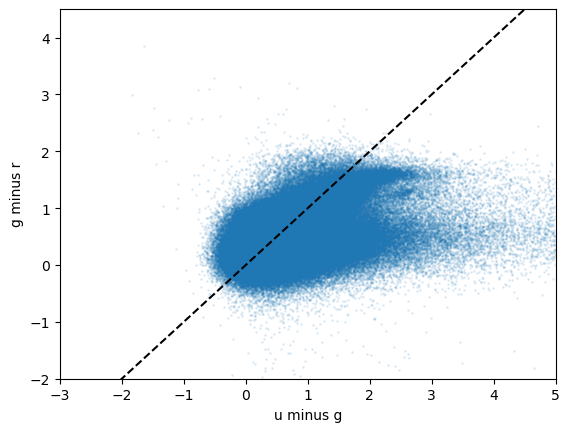

In [121]:
plt.scatter(object_table['u_minus_g'], object_table['g_minus_r'], s = 1, alpha = 0.1)
plt.plot([-10, 10], [-10, 10], 'k--')
plt.xlabel('u minus g')
plt.ylabel('g minus r')
plt.xlim(-3, 5)
plt.ylim(-2, 4.5)

In [98]:
# Slim data if needed

# random2000 = np.random.choice(len(object_table), size=10000, replace=False)
# object_table = object_table[random2000]

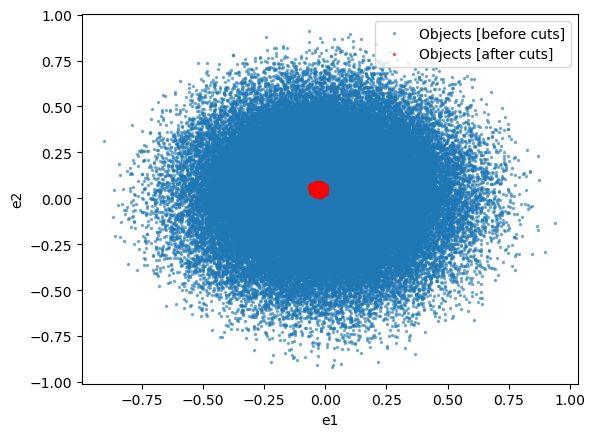

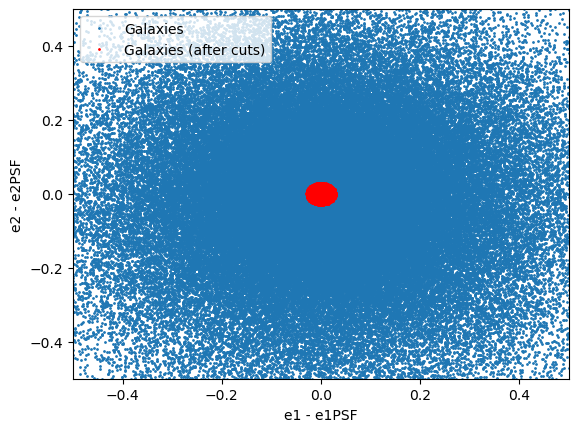

In [99]:
# 2d distribution of e1 and e2 for objects and PSF

# plt.plot(e1PSF[mask], e2PSF[mask], '.', markersize=3, alpha = 0.5, label = 'PSF')
plt.plot(e1, e2, '.', markersize=3, alpha = 0.5, label = 'Objects [before cuts]')
plt.plot(e1[mask], e2[mask], '.', markersize=3, alpha = 0.5, color = 'r', label = 'Objects [after cuts]')
plt.xlabel('e1')
plt.ylabel('e2')
plt.legend()
plt.show()
plt.close()

plt.plot(e1 - e1PSF, e2 - e2PSF, '.', markersize=2, alpha = 1, label = 'Galaxies')
# plt.plot(e1[shape_mask_old] - e1PSF[shape_mask_old], e2[shape_mask_old] - e2PSF[shape_mask_old], '.', color = 'green', markersize=2, alpha = 1, label = 'Objects old mask')
plt.plot(e1[mask] - e1PSF[mask], e2[mask] - e2PSF[mask], '.', color = 'red', markersize = 2, alpha = 1, label = 'Galaxies (after cuts)')
# plt.plot(e1PSF, e2PSF, '.', markersize=3, alpha = 0.5, label = 'PSF')
plt.xlim(-0.5, 0.5)
plt.ylim(-0.5, 0.5)
plt.xlabel('e1 - e1PSF')
plt.ylabel('e2 - e2PSF')
plt.legend()
plt.show()
plt.close()



In [100]:
#Apply your spatial cut to the object table rows (since Butler loads the whole tract)

# Build SkyCoord for your filtered ~100 objects
obj_coords = SkyCoord(ra=object_table['coord_ra'],
                      dec=object_table['coord_dec'])


In [101]:
def source_query(coords):
    search_radius = 2 #arcsec
    search_circles = [f"CONTAINS(POINT('ICRS', ra, dec),CIRCLE('ICRS', {ra}, {dec}, {search_radius/3600}))=1" for ra, dec in np.array([coords['coord_ra'], coords['coord_dec']]).T]
    search_string = " OR ".join(map(str, search_circles))
    
    source_query = f"""SELECT band,
                dec,
                decErr,
                detector,
                ixx,
                ixxPSF,
                ixy,
                ixyPSF,
                iyy,
                iyyPSF,
                ra,
                raErr,
                visit,
                psfFlux,
                psfFluxErr
                
        FROM dp2.Source 
        WHERE (band = 'g' OR band = 'i' or band = 'u' or band = 'r' or band = 'z') AND ({search_string})
        AND psfFluxErr / psfFlux < 0.05
        """
    
        # AND (ixxPSF - iyyPSF) / (ixxPSF + iyyPSF) > -0.02
        # AND (ixxPSF - iyyPSF) / (ixxPSF + iyyPSF) < 0.02
    
                # (ixx - iyy) / (ixx + iyy) AS e1,
                # (2*ixy) / (ixx + iyy) AS e2,
                # (ixxPSF - iyyPSF) / (ixxPSF + iyyPSF) AS e1PSF,
                # (2*ixyPSF) / (ixxPSF + iyyPSF) AS e2PSF
    
    job = service.submit_job(source_query)
    job.run()
    job.wait(phases=['COMPLETED', 'ERROR'])
    print('Job phase is', job.phase)
    if job.phase == 'ERROR':
        job.raise_if_error()
    assert job.phase == 'COMPLETED'
    source_table = job.fetch_result().to_table()
    return source_table

print(len(object_table))
source_table = source_query(object_table[0:100])

3165


KeyboardInterrupt: 

In [ ]:
# get all sources for the objects in the object table
sources = get_all_sources_parallel(ra, dec, search_radius, object_table)

297


In [ ]:
# get all visits for the objects in the object table
visits = get_all_visits(ra, dec, search_radius)


1
visit_table@{instrument: 'LSSTCam'} [sc=ArrowAstropy] (run=LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2/20260325T031924Z id=019d2301-62c9-7b3b-a3a2-78c7d9adabf0)
28698


In [ ]:
# build master table and add additional columns 

master = join(sources, visits, 'visit', metadata_conflicts = 'silent')

master = parallactic_angle_from_radec_fast(master, lat=lat, lon=lon, height=height, sidereal_kind = 'mean')

In [ ]:
# rotate 2nd moments into correct frame
from rotateMoments import rotateXYtoAA, rotateXYtoNW, rotateNWtoAA

# x/y to az/alt 
aaIxx, aaIyy, aaIxy = rotateXYtoNW(master['ixx'], master['iyy'], master['ixy'], master['skyRotation']*np.pi/180 - master['q'])

master['aaIxx'] = aaIxx
master['aaIyy'] = aaIyy
master['aaIxy'] = aaIxy


# x/y to az/alt 
aaIxx, aaIyy, aaIxy = rotateXYtoNW(master['ixxPSF'], master['iyyPSF'], master['ixyPSF'], master['skyRotation']*np.pi/180 - master['q'])

master['aaIxxPSF'] = aaIxx
master['aaIyyPSF'] = aaIyy
master['aaIxyPSF'] = aaIxy




In [ ]:
# Calculate the correct alt/az for each point
from utils import radec_to_altaz_vectorized
ra  = master['ra']
dec = master['dec']
MJD = master['expMidptMJD']
alt, az = radec_to_altaz_vectorized(ra, dec, MJD) #calculate the correct alt/az (the queried values are for the boresight)
master['Z'] = 90 - alt # - alt
master['az'] = az # - az


(array([  96.,  272.,  301.,  376.,  465.,  644.,  823., 1004., 1118.,
        1087., 1146., 1075., 1117., 1099., 1165., 1152., 1138., 1169.,
        1234., 1216., 1208., 1054., 1043.,  964.,  896.,  794.,  712.,
         646.,  605.,  534.,  469.,  412.,  353.,  328.,  343.,  279.,
         212.,  120.,   24.,    5.]),
 array([ 7.66902233,  9.18681301, 10.70460368, 12.22239436, 13.74018503,
        15.25797571, 16.77576638, 18.29355706, 19.81134774, 21.32913841,
        22.84692909, 24.36471976, 25.88251044, 27.40030111, 28.91809179,
        30.43588246, 31.95367314, 33.47146381, 34.98925449, 36.50704517,
        38.02483584, 39.54262652, 41.06041719, 42.57820787, 44.09599854,
        45.61378922, 47.13157989, 48.64937057, 50.16716125, 51.68495192,
        53.2027426 , 54.72053327, 56.23832395, 57.75611462, 59.2739053 ,
        60.79169597, 62.30948665, 63.82727733, 65.345068  , 66.86285868,
        68.38064935]),
 <BarContainer object of 40 artists>)

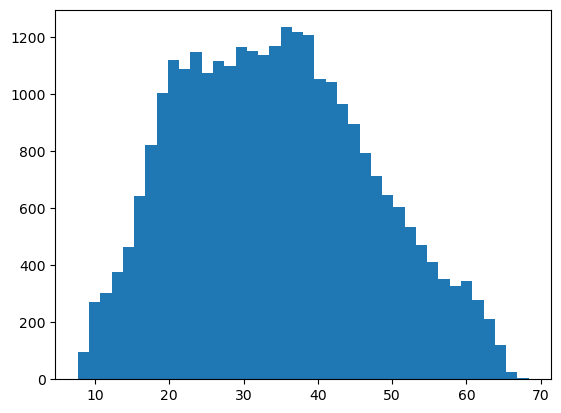

In [35]:

plt.hist(visits['zenithDistance'], bins = 40)

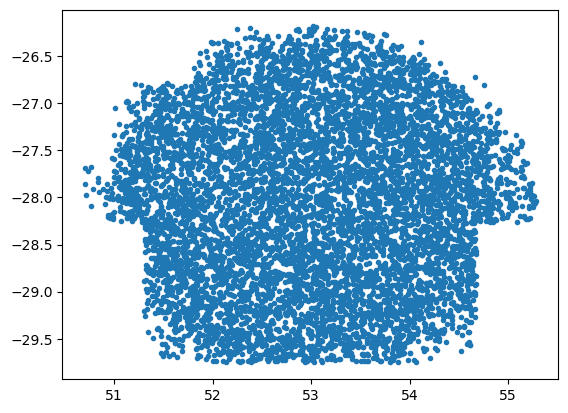

(array([1294.,  308.,  144.,   78.,   48.,   41.,   32.,   21.,    9.,
           3.,    3.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.]),
 array([ 100.        ,  252.63157895,  405.26315789,  557.89473684,
         710.52631579,  863.15789474, 1015.78947368, 1168.42105263,
        1321.05263158, 1473.68421053, 1626.31578947, 1778.94736842,
        1931.57894737, 2084.21052632, 2236.84210526, 2389.47368421,
        2542.10526316, 2694.73684211, 2847.36842105, 3000.        ]),
 <BarContainer object of 19 artists>)

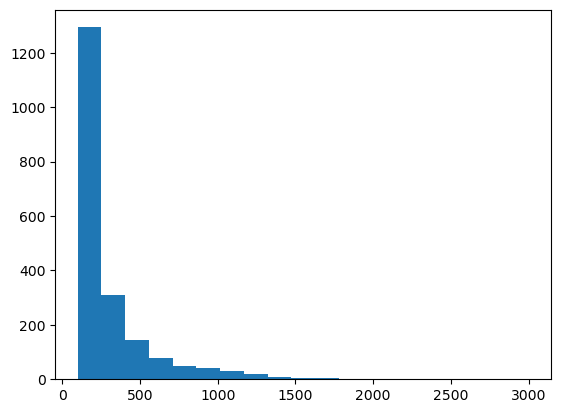

In [38]:
plt.plot(object_table['coord_ra'], object_table['coord_dec'], '.')
plt.show()
plt.close()
# plt.hist(object_table['g_minus_i'])

plt.hist(object_table['g_psfFlux']/object_table['g_psfFluxErr'],  np.linspace(100, 3000, 20))

# plt.hist(object_table['g_psfMag'])

# plt.plot(object_table['g_minus_r'], object_table['r_minus_i'], '.')

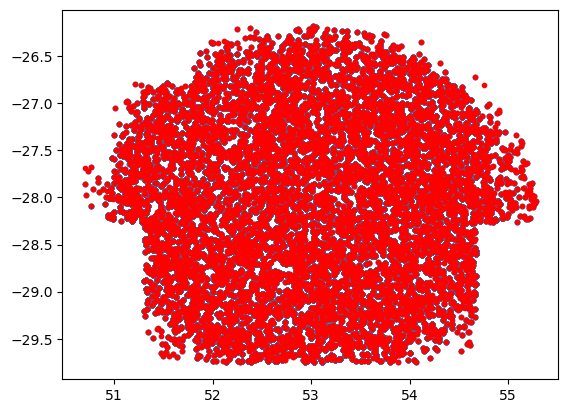

In [40]:
plt.plot(master['ra'], master['dec'], '.', alpha = 0.1)
plt.plot(object_table['coord_ra'], object_table['coord_dec'], 'r.')

In [ ]:

master_sourced = master

(array([ 1.,  7.,  3.,  6., 14., 16., 17., 12., 14., 13.,  9.,  9., 10.,
         9., 11.,  3.,  4.,  4.,  4., 11.,  3.,  6.,  9.,  9.,  1.,  8.,
         3.,  2.,  4.,  1.,  1.,  3.,  0.,  3.,  0.,  0.,  0.,  0.,  0.,
         1.]),
 array([0.94754101, 1.00740743, 1.06727384, 1.12714026, 1.18700667,
        1.24687308, 1.3067395 , 1.36660591, 1.42647233, 1.48633874,
        1.54620515, 1.60607157, 1.66593798, 1.7258044 , 1.78567081,
        1.84553722, 1.90540364, 1.96527005, 2.02513646, 2.08500288,
        2.14486929, 2.20473571, 2.26460212, 2.32446853, 2.38433495,
        2.44420136, 2.50406778, 2.56393419, 2.6238006 , 2.68366702,
        2.74353343, 2.80339985, 2.86326626, 2.92313267, 2.98299909,
        3.0428655 , 3.10273192, 3.16259833, 3.22246474, 3.28233116,
        3.34219757]),
 <BarContainer object of 40 artists>)

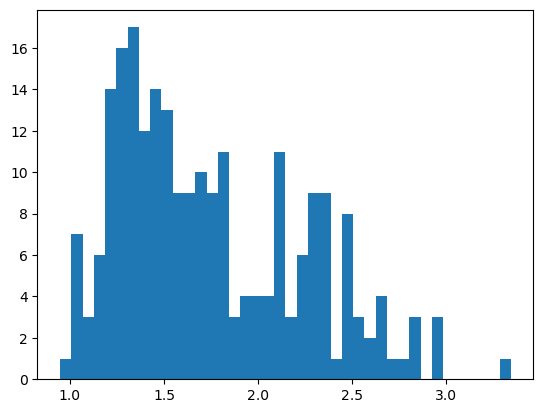

In [45]:
pixel_pitch = 0.2 #arcsec/pixel


FWHMs = []
for visit_id in np.unique(master['visit']):
    visit_mask = (master['visit'] == visit_id)
    master_ = master[visit_mask]

    FWHMs.append(np.median(np.sqrt(master_['aaIxxPSF'] + master_['aaIyyPSF'])) * 2.355) #convert to FWHM

FWHMs = np.array(FWHMs) * pixel_pitch

plt.hist(FWHMs, 40)

In [ ]:
# for loading previously saved data:

# master.write(f'data/2nd_moments/master_COSMOS_gal.fits', format = 'fits')
# object_table.write(f'data/2nd_moments/object_table_COSMOS_gal.ecsv')


# object_table = Table.read(f'data/2nd_moments/object_table_COSMOS_gal.ecsv', format = 'ascii.ecsv')
# master = Table.read(f'data/2nd_moments/master_COSMOS_gal.fits', format = 'fits')
# objT = object_table['g_ixx'] + object_table['g_iyy']
# obje1 = (object_table['g_ixx'] - object_table['g_iyy'])/objT
# obje2 = 2*object_table['g_ixy'] / objT

# plt.hist(obje1, bins = 40, alpha = 0.5, label = 'e1')
# plt.hist(obje2, bins = 40, alpha = 0.5, label = 'e2')

# fields = ['ECDFS', 'ELAISS', 'EDFS']
# for field in fields:
#     object_table_ = Table.read(f'data/2nd_moments/object_table_{field}_gal.ecsv', format = 'ascii.ecsv')
#     master_ = Table.read(f'data/2nd_moments/master_{field}_gal.fits', format = 'fits')

#     objT = object_table_['g_ixx'] + object_table_['g_iyy']
#     obje1 = (object_table_['g_ixx'] - object_table_['g_iyy'])/objT
#     obje2 = 2*object_table_['g_ixy'] / objT

#     plt.hist(obje1, bins = 40, alpha = 0.5, label = 'e1')
#     plt.hist(obje2, bins = 40, alpha = 0.5, label = 'e2')
    

#     object_table = vstack([object_table, object_table_], metadata_conflicts = 'silent')
#     master = vstack([master, master_], metadata_conflicts = 'silent')

# master_sourced = master

In [ ]:
master_sourced = master

pixel_pitch = 0.2 #arcsec/pixel

def rebin(x, y, stepsize = None, newx_edges = None, median = True):

    if newx_edges is None:        
        newx_edges = np.arange(min(x), max(x) + stepsize, stepsize)
    
    newx = newx_edges[0:-1] + (newx_edges[1:] - newx_edges[0:-1])/2
        

    binned_data = np.zeros(len(newx_edges) - 1)    
    binned_err = np.zeros(len(newx_edges) - 1)

    bin_ind = np.digitize(x, newx_edges) - 1
    
    for i in range(len(binned_data)):
        mask = bin_ind == i
        if median:
            newx[i] = np.median(x[mask])
            binned_data[i] = np.median(y[mask])
        else:
            newx[i] = np.mean(x[mask])
            binned_data[i] = np.mean(y[mask])
        binned_err[i] = np.std(y[mask])/np.sqrt(np.sum(mask))

    return newx, binned_data, binned_err

# bin1_ids = object_table['objectId'][(object_table['r_minus_z'] > 0) * (object_table['r_minus_z'] < 0.38)]
# bin2_ids = object_table['objectId'][(object_table['r_minus_z'] > 0.38) * (object_table['r_minus_z'] < 0.82)]
# bin3_ids = object_table['objectId'][(object_table['r_minus_z'] > 0.82) * (object_table['r_minus_z'] < 3.5)]


bin1_ids = object_table['objectId'][(object_table['g_minus_i'] > 0.0) * (object_table['g_minus_i'] < 0.85)]
bin2_ids = object_table['objectId'][(object_table['g_minus_i'] > 0.85) * (object_table['g_minus_i'] < 1.5)]
bin3_ids = object_table['objectId'][(object_table['g_minus_i'] > 1.5) * (object_table['g_minus_i'] < 3.5)]

# print(len(np.unique(master_sourced['objectId'])))

bin1_mask =  np.isin(master_sourced['objectId'], bin1_ids)
# print(len(bin1_mask), np.sum(bin1_mask), len(np.unique(master_sourced['objectId'][bin1_mask])))
bin2_mask = np.isin(master_sourced['objectId'], bin2_ids)
# print(len(bin2_mask), len(master_sourced[bin2_mask]), len(np.unique(master_sourced['objectId'][bin2_mask])))
bin3_mask = np.isin(master_sourced['objectId'], bin3_ids)
# print(len(bin3_mask), np.sum(bin3_mask), len(np.unique(master_sourced['objectId'][bin3_mask])))


# print(len(master_sourced), np.sum(bin1_mask) + np.sum(bin2_mask) + np.sum(bin3_mask))

# print(bin1_ids[0:10])
# print('test', np.isin(master_sourced['objectId'][bin1_mask][0], bin1_ids))

# master_sourced['ixx', 'ixxPSF', 'objectId'][0:10]


T = master_sourced['aaIxx'] + master_sourced['aaIyy']
e1 = -(master_sourced['aaIxx'] - master_sourced['aaIyy']) #/ T
e1 = e1 * pixel_pitch**2 #convert to arcsec^2
e2 = 2*master_sourced['aaIxy'] #/T
e2 = e2 * pixel_pitch**2 #convert to arcsec^2

TPSF = master_sourced['aaIxxPSF'] + master_sourced['aaIyyPSF']
e1PSF = -(master_sourced['aaIxxPSF'] - master_sourced['aaIyyPSF']) #/ TPSF
e1PSF = e1PSF * pixel_pitch**2 #convert to arcsec^2
e2PSF = 2*master_sourced['aaIxyPSF']#/TPSF
e2PSF = e2PSF * pixel_pitch**2 #convert to arcsec^2


E1 = e1 - e1PSF
# E1 = e2 - e2PSF
Z = master_sourced['Z']


tanZ2 = (np.tan(Z * np.pi/180))**2


snr_mask = master_sourced['psfFlux']/master_sourced['psfFluxErr'] > 10
small_obj_mask = T < 60#(master_sourced['ixx'] < 20) * (master_sourced['iyy'] < 20)
nan_mask = ~np.isnan(E1) * ~np.isinf(E1)
band_mask = (master_sourced['band'] == 'g') & snr_mask & nan_mask #& small_obj_mask

z_bins = np.linspace(10, 70, 13)
# tanZ2_bins = np.linspace(min(tanZ2), max(tanZ2), 12)
tanZ2_bins = np.logspace(np.log10(min(tanZ2)/10), np.log10(max(tanZ2)), num= 12)
tanZ2_bins = np.percentile(tanZ2[band_mask], np.linspace(0, 100, 18))

tanZ2_bins = tanZ2_bins[tanZ2_bins > 0.1]
tanZ2_bins = np.append([0, 0.1], tanZ2_bins)

print('pre masked length: ', len(master_sourced))
print('post masked length: ', np.sum( band_mask)) #bin1_mask *

def line_0(x,  p, c):
    return p * x + c
    
popt1, perr1 = curve_fit(line_0, tanZ2[bin1_mask & band_mask], E1[bin1_mask & band_mask])
popt2, perr2 = curve_fit(line_0, tanZ2[bin2_mask & band_mask], E1[bin2_mask & band_mask])
popt3, perr3 = curve_fit(line_0, tanZ2[bin3_mask & band_mask], E1[bin3_mask & band_mask])

print('bin1: ', popt1, np.sqrt(np.diag(perr1))/popt1)
print('bin2: ', popt2, np.sqrt(np.diag(perr2))/popt2)
print('bin3: ', popt3, np.sqrt(np.diag(perr3))/popt3)
Z_ = np.linspace(min(tanZ2), max(tanZ2), 50)


z1, e1, e1_err = rebin(tanZ2[bin1_mask & band_mask], E1[bin1_mask & band_mask],  newx_edges = tanZ2_bins, median = False )
z2, e2, e2_err = rebin(tanZ2[bin2_mask & band_mask], E1[bin2_mask & band_mask], newx_edges = tanZ2_bins, median= False)
z3, e3, e3_err = rebin(tanZ2[bin3_mask & band_mask], E1[bin3_mask & band_mask], newx_edges = tanZ2_bins, median = False)


# plt.plot(Z[bin1_mask & band_mask], E1[bin1_mask & band_mask], 'c.', markersize=1)# alpha = 0.01)
# plt.plot(Z[bin2_mask & band_mask], E1[bin2_mask & band_mask], 'c.', markersize=1) #alpha = 0.01)
# plt.plot(Z[bin3_mask & band_mask], E1[bin3_mask & band_mask], 'c.', markersize=1) #alpha = 0.01, label = 'all sources')



pre masked length:  1129318
post masked length:  114760
bin1:  [0.00964853 0.00180926] [0.06286446 0.84706245]
bin2:  [0.00773931 0.00635975] [0.10201048 0.32013553]
bin3:  [ 0.00177131 -0.00069913] [ 0.8132493  -5.42958677]


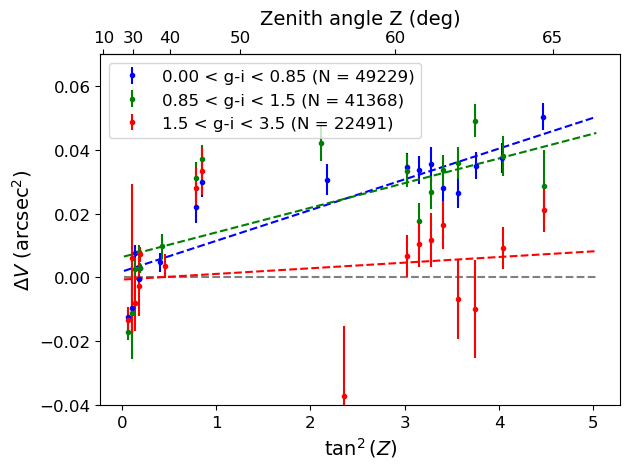

In [51]:


plt.hlines(0, min(tanZ2), max(tanZ2), color = 'grey', ls =  '--' )
plt.errorbar(z1, e1, yerr = e1_err, c = 'b', fmt = '.',  label = f'0.00 < g-i < 0.85 (N = {len(E1[bin1_mask & band_mask])})')
plt.plot(Z_, line_0(Z_, *popt1), 'b--')
plt.errorbar(z2, e2, yerr = e2_err, c = 'g', fmt = '.', label = f'0.85 < g-i < 1.5 (N = {len(E1[bin2_mask & band_mask])})')
plt.plot(Z_, line_0(Z_, *popt2), 'g--')
plt.errorbar(z3, e3, yerr = e3_err, c = 'r', fmt = '.', label = f'1.5 < g-i < 3.5 (N = {len(E1[bin3_mask & band_mask])})')
plt.plot(Z_, line_0(Z_, *popt3), 'r--')

plt.legend(loc='upper left', fontsize = 12)
plt.xlabel(r'$\tan^2(Z)$', fontsize = 14)
# plt.ylabel(r'$(I_{yy} - I_{xx}) - (I_{yy} - I_{xx})_\text{PSF}$ (arcsec$^2$)', fontsize = 14)
plt.ylabel(r'$\Delta V$ (arcsec$^2$)', fontsize = 14)
# plt.ylabel(r'$2*I_{xy} - (2*I_{xy})_\text{PSF}$ (arcsec$^2$)', fontsize = 14)
# plt.ylabel(r'Trace Residual $(T - T_\text{PSF})/T$ ', fontsize = 12)
# plt.ylabel('g-band: e1 - e1PSF')
# plt.xscale('log')
# plt.xlim(0, 70)
# plt.title(r'Galaxies (g-band)', fontsize = 16)
plt.ylim(-0.04, 0.07)
plt.tick_params(axis='both', which='major', labelsize=12)

def tan2_to_z_deg(t2):
    return np.degrees(np.arctan(np.sqrt(np.clip(np.asarray(t2), 0, None))))

def z_deg_to_tan2(z):
    return np.tan(np.radians(np.asarray(z)))**2

zenith_ticks_deg = np.array([10, 30, 40, 50, 60, 65])

secax = plt.gca().secondary_xaxis('top', functions=(tan2_to_z_deg, z_deg_to_tan2))
secax.set_xlabel('Zenith angle Z (deg)', fontsize = 14)
secax.set_xticks(zenith_ticks_deg)
secax.set_xticklabels(['10', '30', '40', '50', '60', '65'], fontsize = 12)

plt.tight_layout()

# plt.savefig(f'plots/galaxy_e1_residual_vs_tanZ2_color_bins.pdf')

Text(0, 0.5, 'Number of sources')

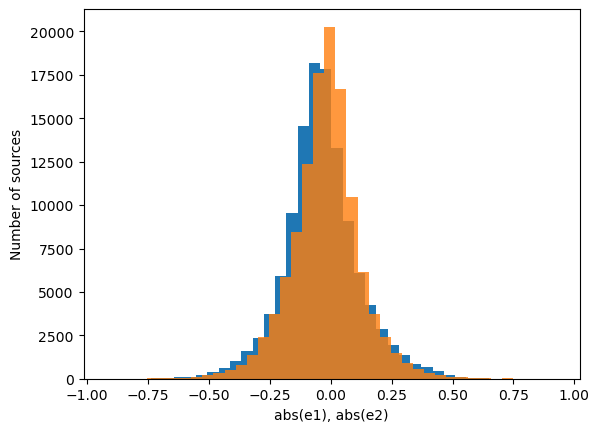

In [55]:
T = master_sourced['aaIxx'] + master_sourced['aaIyy']
e1 = (master_sourced['aaIxx'] - master_sourced['aaIyy'])/T
e2 = 2*master_sourced['aaIxy'] / T

plt.hist(e1[band_mask], 40)
plt.hist(e2[band_mask], 40, alpha = 0.8)

plt.xlabel('abs(e1), abs(e2)')
plt.ylabel('Number of sources')

AttributeError: PathCollection.set() got an unexpected keyword argument 'markersize'

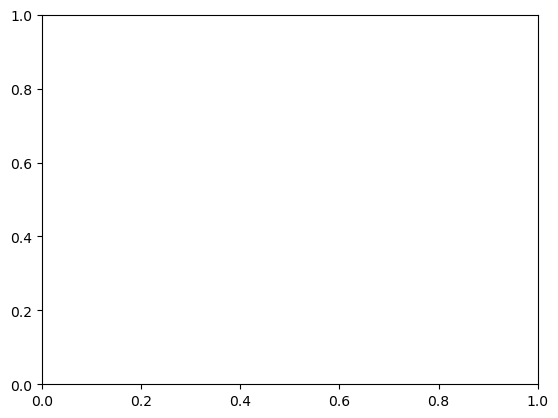

In [53]:

snr_mask = master_sourced['psfFlux']/master_sourced['psfFluxErr'] > 10
small_obj_mask = T < 60#(master_sourced['ixx'] < 20) * (master_sourced['iyy'] < 20)
nan_mask = ~np.isnan(E1) * ~np.isinf(E1)
band_mask = (master_sourced['band'] == 'r') & snr_mask & nan_mask #& small_obj_mask

DeltaVs = []
Ts = []
gal_colors = []

for obj in object_table:
    id = obj['objectId']
    # print(id)
    mask = master['objectId'] == id
    # print(np.sum(mask))
    if len(E1[mask * band_mask]) > 20:

        de1_ = E1[mask * band_mask] 
        tanZ2_ = tanZ2[mask * band_mask]

        popt, perr = curve_fit(line_0, tanZ2_, de1_)
        DeltaVs.append(popt[0])
        gal_colors.append(obj['g_minus_i'])

        Ts.append(np.median(T[mask * band_mask]))

    

DeltaVs = np.array(DeltaVs)
Ts = np.array(Ts)
pixel_pitch = 0.2 #arcsec/pixel

sc = plt.scatter(Ts * pixel_pitch**2, DeltaVs * pixel_pitch**2, c = gal_colors, markersize = 1)
plt.colorbar(sc, label = 'g-i color')
plt.xlabel('g-i color')
plt.ylabel(r'$\Delta V$ (arcsec$^2$)')
plt.xlim(-1, 4)
plt.ylim(-0.5, 0.5)
plt.show()
plt.close()

plt.hist(DeltaVs * pixel_pitch**2, bins = 80)
plt.xlim(-1, 1)
print(np.median(DeltaVs * pixel_pitch**2), np.mean(DeltaVs * pixel_pitch**2))

[0.         0.1        0.11414346 0.16891052 0.41051649 0.44797523
 0.49255761 1.25667327 1.33954944 1.40385365 1.47653537 1.60366271
 2.15967894 2.42313633 3.20027613 5.00571028]


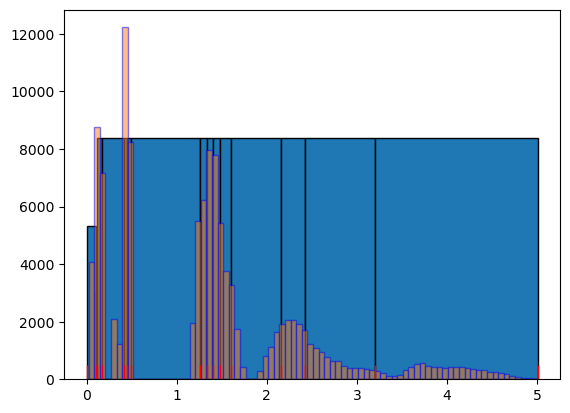

In [54]:
base = 10
tanZ2_bins = np.logspace(np.log(min(tanZ2[band_mask])/100)/np.log(base), np.log(max(tanZ2[band_mask]))/np.log(base), num= 18, base = base)
Z_bins = np.logspace(np.log10(min(Z[band_mask])), np.log10(max(Z[band_mask])), num= 12)

bins = np.percentile(tanZ2[band_mask], np.linspace(0, 100, 15))
bins = bins[bins > 0.1]
bins = np.append([0, 0.1], bins)
plt.hist(tanZ2[band_mask], bins, edgecolor = 'k')
plt.hist(tanZ2[band_mask],80, edgecolor = 'b', alpha = 0.5)
plt.plot(bins, np.zeros(len(bins)), 'r|', markersize = 20)

print(bins)
# mask2 = tanZ2 < 0.1
# n, bins, patches = plt.hist(tanZ2[band_mask * mask1], 7)
# n, bins, patches = plt.hist(tanZ2[band_mask * mask2], 2)


In [ ]:
psf_mask = object_table['g_calib_psf_used'] == True
# bins = [0, 0.38, 0.82, 3.5]
n, bins, patches = plt.hist(object_table['g_minus_i'], bins = 20)
plt.hist(object_table['g_minus_i'][psf_mask], bins = bins)
print(np.mean(object_table['g_minus_i'][psf_mask]), np.std(object_table['g_minus_i'][psf_mask]))

print(bins)

In [ ]:
i = 3
print(i)
obj_mask = master['objectId'] == object_table['objectId'][i]
band_mask = master['band'] == 'g'

z = master['zenithDistance'][obj_mask * band_mask]
dR = master['dR'][obj_mask * band_mask]

print(object_table['g_r45'][i] * 3600 * 1000)
print(object_table['coord_ra', 'coord_dec'][i])
plt.plot(z, dR * 3600 * 1000, '.')
plt.plot(range(47), np.zeros(47), 'k--')

# plt.xlim(